# Serial Position Curve

> Reveal primacy and recency effects in free recall.

The serial position curve (SPC) is one of the most robust findings in memory research: when people study a list of items and then freely recall them, recall probability varies systematically with study position. Items from the beginning of the list (primacy) and end of the list (recency) are recalled more often than items from the middle.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.spc import plot_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 3"
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

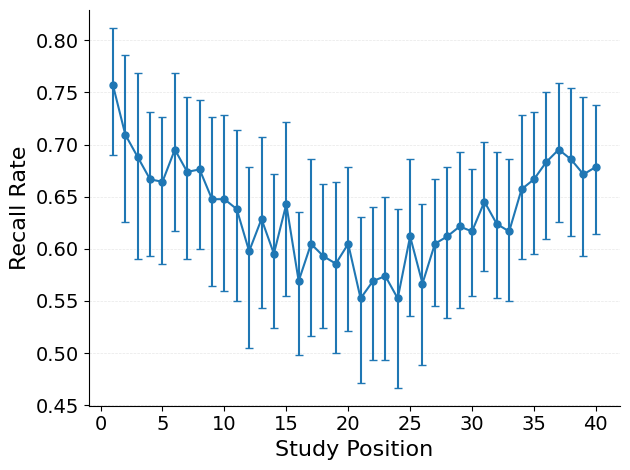

In [4]:
plot_spc(data, trial_mask, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows study position and the y-axis shows recall probability. Key patterns to look for:

- **Primacy effect**: elevated recall for the first few positions, reflecting stronger encoding or rehearsal of early items.
- **Recency effect**: elevated recall for the last few positions, reflecting items still active in short-term memory.
- **Asymptote**: the relatively flat middle portion indicates baseline recall for items that benefit from neither primacy nor recency.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `size` — maximum number of study positions a single item can occupy. Use 1 for non-repeating lists.
- `confidence_level` — confidence level for subject-wise error bars.
